In [1]:
%load_ext autoreload
%autoreload 2

****************************************
# Galactic Crab Analysis — Data Challenge 2

This notebook analyzes the **DC2 Crab observation** with COSIpy and 3ML.

The simulated source contains the combined **pulsar + nebula emission** from
**100 keV to 10 MeV**. This analysis has two connected goals:

1. Detect the Crab by comparing source-plus-background and background-only hypotheses.
2. Measure its phase-integrated spectrum with a power-law model.

The observation is integrated over time, so the result describes the total
phase-integrated emission rather than the pulsar light curve.
****************************************


## Contents

- [Setup](#toc-setup)
  - [Imports](#toc-imports)
  - [Data files](#toc-data)
  - [Analysis inputs](#toc-inputs)
- [Prepare the binned observation](#toc-binning-data)
  - [Bin or load DC2 and background data](#toc-background-binning)
  - [Inspect the binned data](#toc-exploring-binned-data)
- [Inspect the detector response](#toc-detector-response)
- [DC2 Crab detection and spectrum](#toc-dc2-detection)
  - [Prepare the observed counts](#toc-dc2-counts)
  - [Build the source response](#toc-dc2-source-response)
  - [Prepare the background and 3ML plugin](#toc-dc2-plugin)
  - [Define the phase-integrated spectrum](#toc-dc2-spectrum)
  - [Run and inspect the fit](#toc-dc2-fit)
  - [Test the Crab detection](#toc-dc2-ts)


<a id="toc-setup"></a>
## Setup


<a id="toc-imports"></a>
### Imports


In [2]:
from pathlib import Path
import sys

# Repository and numerical tools
repo_root = Path.cwd().parent
import numpy as np
import matplotlib.pyplot as plt

# COSIpy interfaces
import cosipy as cp
from cosipy.statistics import PoissonLikelihood
from cosipy.interfaces import ThreeMLPluginInterface

# Physical units and 3ML source-model tools
import astropy.units as u
from threeML import PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Powerlaw, clone_model

%matplotlib inline


<a id="toc-data"></a>
### Data Files

Define the DC2 observation, background, orientation, detector-response, and
cached binned-data paths used throughout the notebook.


In [3]:
data_dir = repo_root / "data"

# Unbinned DC2 Crab events and matching simulated background events
data_crab_dc2 = data_dir / "data-products/downloads/Crab_DC2_3months_unbinned_data.fits.gz"
data_background = data_dir / "backgrounds/downloads/total_bg_3months_unbinned_data.fits.gz"

# Spacecraft attitude history and full detector response
data_orientation = data_dir / "data-products/downloads/20280301_3_month_with_orbital_info.fits"
data_response = data_dir / (
    "data-products/downloads/"
    "SMEXv12.Continuum.HEALPixO3_10bins_log_flat."
    "binnedimaging.imagingresponse.h5"
)

# Reusable binned products generated from the event files
crab_dc2_binned = data_dir / "data-products/binned/crab_binned_data_dc2.hdf5"
background_binned = data_dir / "backgrounds/binned/background_binned_data.hdf5"


<a id="toc-inputs"></a>
### Analysis Inputs

The Crab position is fixed because this task concerns detection and spectral
measurement, not localization.


In [4]:
# Known Galactic coordinates of the Crab
l_crab = 184.55746
b_crab = -5.78436


***
<a id="toc-binning-data"></a>
## Prepare the Binned Observation

The event lists are converted to the common analysis axes defined in
`inputs.yaml`. Existing HDF5 products are loaded instead of regenerated.


<a id="toc-background-binning"></a>
### Bin or Load DC2 and Background Data


In [5]:
# Separate objects use the same inputs.yaml definition, ensuring that the
# DC2 observation and background have compatible analysis axes.
analysis_dc2 = cp.BinnedData("inputs.yaml")
analysis_background = cp.BinnedData("inputs.yaml")


In [6]:
# Generate each binned product only when it does not already exist.
if not crab_dc2_binned.exists():
    analysis_dc2.get_binned_data(
        unbinned_data=str(data_crab_dc2),
        output_name=str(crab_dc2_binned.with_suffix("")),
    )

if not background_binned.exists():
    analysis_background.get_binned_data(
        unbinned_data=str(data_background),
        output_name=str(background_binned.with_suffix("")),
    )

# Loading attaches the histogram contents and metadata to the in-memory objects,
# whether each file was generated above or already existed.
analysis_dc2.load_binned_data_from_hdf5(binned_data=str(crab_dc2_binned))
analysis_background.load_binned_data_from_hdf5(binned_data=str(background_binned))


In [7]:
# Confirm that the cached products were found and display their bin definitions.
analysis_dc2.get_binning_info()
analysis_background.get_binning_info()

print("Crab DC2 binned data exists:", crab_dc2_binned.exists())
print("Background binned data exists:", background_binned.exists())


Crab DC2 binned data exists: True
Background binned data exists: True


<a id="toc-exploring-binned-data"></a>
### Inspect the Binned Data

These checks verify the dimensions and physical binning before constructing the
likelihood analysis.


In [8]:
print("Crab DC2 binned-data shape:", analysis_dc2.binned_data.shape)
print("Background binned-data shape:", analysis_background.binned_data.shape)

print("Time centers:", analysis_dc2.time_bin_centers)
print("Time widths:", analysis_dc2.time_bin_widths)
print("Energy centers:", analysis_dc2.energy_bin_centers)
print("Energy edges:", analysis_dc2.energy_bin_edges)
print("Energy widths:", analysis_dc2.energy_bin_widths)


Crab DC2 binned-data shape: (1108, 10, 36, 768)
Background binned-data shape: (1108, 10, 36, 768)
Time centers: [1.83549129e+09 1.83549849e+09 1.83550569e+09 ... 1.84344866e+09
 1.84345586e+09 1.84346306e+09] s
Time widths: [7201.24278307 7201.24278307 7201.24278331 ... 7201.24278331 7201.24278307
 7201.24278307] s
Energy centers: [ 129.2445  204.839   324.648   514.532   815.4785 1292.445  2048.39
 3246.48   5145.32   8154.785 ] keV
Energy edges: [  100.      158.489   251.189   398.107   630.957  1000.     1584.89
  2511.89   3981.07   6309.57  10000.   ] keV
Energy widths: [  58.489   92.7    146.918  232.85   369.043  584.89   927.    1469.18
 2328.5   3690.43 ] keV


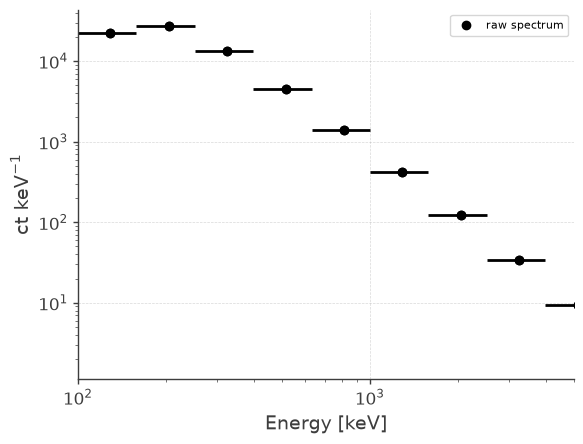

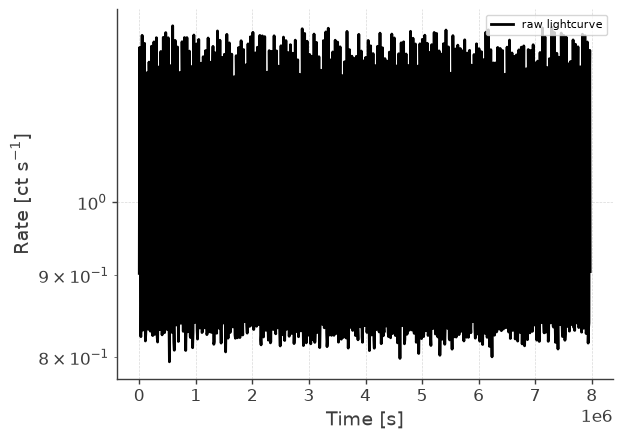

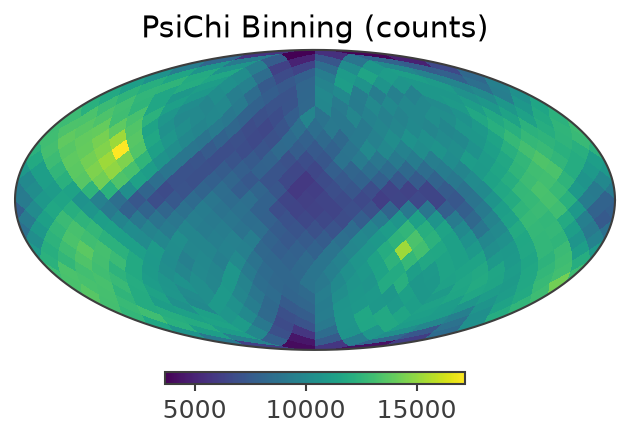

In [9]:
# Optional diagnostic views of the binned DC2 observation.
analysis_dc2.get_raw_spectrum(show_plots=True)
analysis_dc2.get_raw_lightcurve(show_plots=True)
analysis_dc2.plot_psichi_map(show_plots=True, save_plots=False)


***
<a id="toc-detector-response"></a>
## Inspect the Detector Response

The detector response maps incident photons to measured COSI quantities. This
cell is diagnostic; the following section connects it explicitly to DC2.


In [10]:
# Inspect the response axes and sky pixelization.
with cp.response.FullDetectorResponse.open(data_response) as response:
    print("Response axes:", response.axes.labels)
    print(repr(response))
    print(f"NSIDE = {response.nside}")
    print(f"SCHEME = {response.scheme}")
    print(f"NPIX = {response.npix}")
    print(f"Pixel size = {np.sqrt(response.pixarea()).to(u.deg):.2f}")


Response axes: ['NuLambda' 'Ei' 'Em' 'Phi' 'PsiChi']
FILENAME: '/Users/maura/Documents/COSI/data-challenge-2/data/data-products/downloads/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 768
    NSIDE: 8
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 36
    EDGES: [0.0 deg, 5.0 deg, 10.0 deg, 15

***
<a id="toc-dc2-detection"></a>
## DC2 Crab Detection and Phase-Integrated Spectrum

The observation is modeled as a point-source Crab component plus adjustable
background. The first fit measures the spectrum; an independent background-only
fit supplies the null hypothesis for the detection TS.


<a id="toc-dc2-counts"></a>
#### Prepare the Observed Counts


In [11]:
# Integrate the Crab and background histograms over time. The remaining axes
# are measured energy (Em), Compton angle (Phi), and direction (PsiChi).
dc2_source_counts = analysis_dc2.binned_data.project("Em", "Phi", "PsiChi")
bg_source_counts = analysis_background.binned_data.project("Em", "Phi", "PsiChi")

# The simulated observation contains both Crab and background events.
data_dc2 = cp.data_io.EmCDSBinnedData(dc2_source_counts + bg_source_counts)

print("DC2 analysis axes:", data_dc2.axes.labels)
print("DC2 analysis shape:", data_dc2.data.shape)


DC2 analysis axes: ['Em' 'Phi' 'PsiChi']
DC2 analysis shape: (10, 36, 768)


<a id="toc-dc2-source-response"></a>
#### Build the DC2 Source Response

The detector response is adapted to the DC2 binning and combined with the
spacecraft orientation. It can then convert trial spectra into expected counts.


In [12]:
# Load the attitude history and adapt the detector response to data_dc2.
orientation = cp.SpacecraftHistory.open(data_orientation)
detector_response = cp.response.FullDetectorResponse.open(data_response)
instrument_response_dc2 = cp.response.BinnedInstrumentResponse(
    detector_response,
    data_dc2,
)

# Build the response used to translate a point-source spectrum into expected
# counts in every bin of the DC2 observation.
psr_dc2 = cp.response.BinnedThreeMLPointSourceResponse(
    data=data_dc2,
    instrument_response=instrument_response_dc2,
    sc_history=orientation,
    energy_axis=detector_response.axes["Ei"],
    polarization_axis=(
        detector_response.axes["Pol"]
        if "Pol" in detector_response.axes.labels
        else None
    ),
    nside=2 * data_dc2.axes["PsiChi"].nside,
)


In [13]:

################################################################################
# Connect the DC2 point-source response to the 3ML folding interface.           #
################################################################################

# Connect the DC2 point-source response to the spectral models tested by 3ML.
#
# During the fit, each candidate spectrum will pass through this object and
# become a prediction of the counts that COSI should measure in every data bin.

response_dc2 = cp.response.BinnedThreeMLModelFolding(
    data=data_dc2,
    point_source_response=psr_dc2,
)



<a id="toc-dc2-plugin"></a>
#### Prepare the Background and 3ML Plugin

The fixed background shape, its adjustable normalization, the Poisson
likelihood, and the COSI–3ML interface are configured here.


In [14]:
################################################################################
# Keep the background shape fixed while fitting its total normalization.        #
################################################################################

# Store an independent copy of the background distribution for DC2.
background_distribution_dc2 = {
    "total_background": bg_source_counts.copy()
}

# Add a tiny positive floor to prevent zero expected counts.
#
# A Poisson likelihood becomes infinite when an observed bin contains events
# but the source-plus-background expectation in that bin is exactly zero.
for background_label in background_distribution_dc2:
    background_distribution_dc2[
        background_label
    ] += sys.float_info.min

# Keep the background shape fixed while allowing its total normalization
# to change during the DC2 fit.
background_model_dc2 = (
    cp.background_estimation.FreeNormBinnedBackground(
        background_distribution_dc2,
        sc_history=orientation,
        copy=False,
    )
)

In [15]:
################################################################################
# Connect the DC2 Poisson likelihood and response to the 3ML framework.          #
################################################################################

# Compare the observed DC2 counts with the source-plus-background prediction
# using a Poisson likelihood for binned event counts.
like_dc2_fun = PoissonLikelihood(
    data_dc2,
    response_dc2,
    background_model_dc2,
)

# Expose the DC2 likelihood, response, and background model to 3ML.
cosi_dc2 = ThreeMLPluginInterface(
    "cosi_dc2",
    like_dc2_fun,
    response_dc2,
    background_model_dc2,
)

In [16]:
################################################################################
# Define the adjustable normalization of the DC2 background component.          #
################################################################################

# Register one adjustable normalization parameter for each DC2 background
# component. In this analysis there is only one: total_background.
for background_label in background_distribution_dc2:
    cosi_dc2.bkg_parameter[background_label] = Parameter(
        background_label,
        1,          # Initial normalization
        min_value=0,
        max_value=100,
        delta=0.05,   # Initial optimizer step size
        unit=u.Hz,
    )

<a id="toc-dc2-spectrum"></a>
#### Define the DC2 Phase-Integrated Spectral Model


In [17]:
################################################################################
# The DC2 phase-integrated Crab spectrum follows a power law. The initial values below #
# are based on the spectrum tabulated in the official DC2 source library.      #
# They provide the optimizer with a reasonable starting point but are not the  #
# final measured values.                                                        #
################################################################################

# Initial power-law parameters for the combined pulsar and nebula spectrum.
dc2_index_initial = -2.2
dc2_K_initial = 6.858e-4 / u.cm / u.cm / u.s / u.keV
dc2_piv = 100.0 * u.keV

# Create the power-law spectral model.
spectrum_dc2 = Powerlaw()

# Define the allowed parameter ranges.
spectrum_dc2.index.min_value = -5.0
spectrum_dc2.index.max_value = 0.0

spectrum_dc2.K.min_value = 1e-12
spectrum_dc2.K.max_value = 1e-2

# Set the initial optimizer step sizes.
spectrum_dc2.index.delta = 0.01
spectrum_dc2.K.delta = 1e-5

# Assign the initial values.
spectrum_dc2.index.value = dc2_index_initial
spectrum_dc2.K.value = dc2_K_initial.value
spectrum_dc2.piv.value = dc2_piv.value

# Assign the physical units.
spectrum_dc2.K.unit = dc2_K_initial.unit
spectrum_dc2.piv.unit = dc2_piv.unit

# Keep the pivot energy fixed. It is a reference energy, not a quantity
# that needs to be measured by the fit.
spectrum_dc2.piv.free = False

The current value of the parameter K (1.0) was above the new maximum 0.01.


#### Create the DC2 Crab Source Model

In [18]:
################################################################################
# Combine the known Crab position with its DC2 power-law spectrum.               #
################################################################################

# Define the Crab as a point source at its known Galactic coordinates.
source_dc2 = PointSource(
    "source_dc2",
    l=l_crab,
    b=b_crab,
    spectral_shape=spectrum_dc2,
)

# Keep the position fixed because the DC2 goal is detection and spectral
# measurement, not localization.
source_dc2.position.l.free = False
source_dc2.position.b.free = False

# Package the source into the astrophysical model used by 3ML.
model_dc2 = Model(source_dc2)

<a id="toc-dc2-fit"></a>
#### Run and Inspect the DC2 Maximum-Likelihood Fit


In [19]:
################################################################################
# Fit the DC2 source and background parameters with 3ML.                        #
################################################################################

# Place the COSI DC2 plugin inside a 3ML DataList.
#
# A DataList can contain several instruments or datasets. In this analysis,
# it contains only the DC2 COSI observation.
plugins_dc2 = DataList(cosi_dc2)

# Connect the DC2 source model with the observed-data plugin.
#
# This configures the analysis but does not run the optimizer yet.
like_dc2 = JointLikelihood(
    model_dc2,
    plugins_dc2,
    verbose=False,
)

# Run the maximum-likelihood fit.
#
# 3ML starts from the initial values assigned to spectrum_dc2 and varies:
#
# - Power-law normalization K
# - Power-law index
# - Total background normalization
#
# The Crab position and pivot energy remain fixed.
_ = like_dc2.fit()

The current value of the parameter K (1.0) was above the new maximum 0.01.


Best fit values:

,result,unit
parameter,,
source_dc2.spectrum.main.Powerlaw.K,(6.358 +/- 0.021) x 10^-4,1 / (keV s cm2)
source_dc2.spectrum.main.Powerlaw.index,-2.1101 +/- 0.0025,
total_background,(3.19836 +/- 0.00029) x 10,Hz


Correlation matrix:

1.00,-0.80,-0.29
-0.80,1.00,-0.15
-0.29,-0.15,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_dc2,-1719831743.8640046
total,-1719831743.8640046


Values of statistical measures:

,statistical measures
AIC,-3439663481.7279224
BIC,-3439663450.138328


In [20]:
# Inspect the DC2 Fit results

# Retrieve the results produced by the DC2 maximum-likelihood fit.
results_dc2 = like_dc2.results

# Display the fitted parameter values, uncertainties, correlation matrix,
# likelihood value, and statistical measures.
results_dc2.display()

# Display the complete optimized source model.
print(results_dc2.optimized_model["source_dc2"])

Best fit values:

,result,unit
parameter,,
source_dc2.spectrum.main.Powerlaw.K,(6.358 +/- 0.021) x 10^-4,1 / (keV s cm2)
source_dc2.spectrum.main.Powerlaw.index,-2.1101 +/- 0.0025,
total_background,(3.19836 +/- 0.00029) x 10,Hz


Correlation matrix:

1.00,-0.80,-0.29
-0.80,1.00,-0.15
-0.29,-0.15,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_dc2,-1719831743.8640046
total,-1719831743.8640046


Values of statistical measures:

,statistical measures
AIC,-3439663481.7279224
BIC,-3439663450.138328


The current value of the parameter K (1.0) was above the new maximum 0.01.


  * source_dc2 (point source):
    * position:
      * l:
        * value: 184.55746
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -5.78436
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Powerlaw:
          * K:
            * value: 0.0006358460676540967
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-12
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 100.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -2.1101437272522485

In [21]:
print("Fitted K:", results_dc2.optimized_model[
    "source_dc2"
].spectrum.main.Powerlaw.K)

print("Fitted index:", results_dc2.optimized_model[
    "source_dc2"
].spectrum.main.Powerlaw.index)

print(
    "Fitted background normalization:",
    cosi_dc2.bkg_parameter["total_background"],
)

The current value of the parameter K (1.0) was above the new maximum 0.01.
The current value of the parameter K (1.0) was above the new maximum 0.01.


Fitted K: Parameter K = 0.0006358460676540967 [1 / (keV s cm2)]
(min_value = 1e-12, max_value = 0.01, delta = 1e-05, free = True)
Fitted index: Parameter index = -2.1101437272522485 []
(min_value = -5.0, max_value = 0.0, delta = 0.01, free = True)
Fitted background normalization: Parameter total_background = 31.98355499494987 [Hz]
(min_value = 0.0, max_value = 100.0, delta = 0.05, free = True)


<a id="toc-dc2-ts"></a>
#### Test the Crab Detection

The test statistic compares two independently optimized hypotheses:

- **Alternative:** Crab plus background.
- **Null:** background only.

The null response, plugin, and background are separate so cached predictions or
fitted parameter values cannot leak between the two hypotheses.


In [22]:
# Create an independent model-folding object for the null hypothesis.
#
# It can reuse psr_dc2 because the instrumental point-source response does
# not change. A new folding object is required so that it has its own model
# cache, separate from the Crab-plus-background fit.

response_null_dc2 = cp.response.BinnedThreeMLModelFolding(
    data=data_dc2,
    point_source_response=psr_dc2,
)

In [23]:
# Create an independent background distribution for the null hypothesis.
#
# Its shape is identical to the DC2 background, but it must belong to a
# separate background model so the null fit cannot modify the alternative fit.

background_distribution_null_dc2 = {
    "total_background": bg_source_counts.copy()
}

# Prevent exactly zero expectations in populated bins.
for background_label in background_distribution_null_dc2:
    background_distribution_null_dc2[
        background_label
    ] += sys.float_info.min

# Create the independent adjustable background model.
background_model_null_dc2 = (
    cp.background_estimation.FreeNormBinnedBackground(
        background_distribution_null_dc2,
        sc_history=orientation,
        copy=False,
    )
)

In [24]:
# Build an independent Poisson likelihood for the null hypothesis.
like_null_dc2_fun = PoissonLikelihood(
    data_dc2,
    response_null_dc2,
    background_model_null_dc2,
)

# Create a separate 3ML plugin for the null hypothesis.
#
# This prevents the background-only fit from sharing the model cache
# used by the Crab-plus-background fit.
cosi_null_dc2 = ThreeMLPluginInterface(
    "cosi_null_dc2",
    like_null_dc2_fun,
    response_null_dc2,
    background_model_null_dc2,
)

In [25]:
# Register an independent background-normalization parameter for the
# background-only hypothesis.
#
# This allows the null fit to find its own best background normalization
# instead of being forced to use the value obtained with the Crab present.

for background_label in background_distribution_null_dc2:
    cosi_null_dc2.bkg_parameter[background_label] = Parameter(
        background_label,
        1.0,
        min_value=0,
        max_value=100,
        delta=0.05,
        unit=u.Hz,
    )

In [26]:


# Clone the optimized model to preserve the successful DC2 spectral fit.
null_model_dc2 = clone_model(
    results_dc2.optimized_model
)

# Access the Crab normalization in the copied model.
null_K_dc2 = (
    null_model_dc2["source_dc2"]
    .spectrum.main.Powerlaw.K
)

# Make the Crab contribution effectively zero and prevent the null fit
# from increasing it again.
null_K_dc2.min_value = 1e-50
null_K_dc2.value = 1e-50
null_K_dc2.free = False

# The index cannot be measured when the source normalization is zero,
# so it must also remain fixed in the null hypothesis.
null_model_dc2[
    "source_dc2"
].spectrum.main.Powerlaw.index.free = False

The current value of the parameter K (1.0) was above the new maximum 0.01.
The current value of the parameter K (1.0) was above the new maximum 0.01.


In [27]:
# Save the negative log-likelihood obtained with Crab plus background.
alternative_nll_dc2 = like_dc2.current_minimum

# Connect the null hypothesis exclusively to its independent COSI plugin.
plugins_null_dc2 = DataList(cosi_null_dc2)

# Build the background-only likelihood analysis.
like_null_dc2 = JointLikelihood(
    null_model_dc2,
    plugins_null_dc2,
    verbose=False,
)

# Fit the null hypothesis.
#
# The Crab normalization and index are fixed, so only the independent
# background normalization is optimized.
_ = like_null_dc2.fit(
    compute_covariance=False
)

External parameter total_background already exist in the model. Overwriting it...
The current value of the parameter K (1.0) was above the new maximum 0.01.


Best fit values:


WARNING RuntimeWarning: divide by zero encountered in log10


WARNING RuntimeWarning: divide by zero encountered in log10


WARNING UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.



,result,unit
parameter,,
total_background,(3.302667985891314 +/- 0) x 10,Hz


Correlation matrix:

nan


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_null_dc2,-1719695407.4341311
total,-1719695407.4341311


Values of statistical measures:

,statistical measures
AIC,-3439390812.868248
BIC,-3439390802.3383684


In [28]:
# Store the minimum negative log-likelihood for the background-only fit.
null_nll_dc2 = like_null_dc2.current_minimum

# Calculate the likelihood-ratio test statistic.
#
# Smaller NLL values correspond to better fits. Therefore, a positive TS
# means that Crab plus background fits better than background alone.
ts_detection_dc2 = 2.0 * (
    null_nll_dc2 - alternative_nll_dc2
)

print(
    "Alternative NLL (Crab + background):",
    alternative_nll_dc2,
)

print(
    "Null NLL (background only):",
    null_nll_dc2,
)

print(
    "Crab detection TS:",
    ts_detection_dc2,
)

Alternative NLL (Crab + background): -1719831743.8640046
Null NLL (background only): -1719695407.4341311
Crab detection TS: 272672.859746933


<a id="toc-dc2-spectrum-uncertainty"></a>
#### Propagate the Spectral Uncertainty

The fit provides uncertainties and correlations for the power-law
normalization and index. These parameter uncertainties are propagated through
the power-law equation to determine the uncertainty of the recovered flux at
each energy.

In [29]:

# Collect the probability distributions of the free source parameters.
#
# For this power-law model, these are K and index. Using get_variates()
# preserves both their uncertainties and their fitted correlation.
free_parameters_dc2 = {
    parameter.name: results_dc2.get_variates(parameter.path)
    for parameter in results_dc2.optimized_model[
        "source_dc2"
    ].parameters.values()
    if parameter.free
}

# Propagate the fitted parameter uncertainties through the power-law equation.
#
# The resulting object can be evaluated at any energy to obtain the median
# fitted flux and its uncertainty interval.
spectrum_uncertainty_dc2 = results_dc2.propagate(
    results_dc2.optimized_model[
        "source_dc2"
    ].spectrum.main.shape.evaluate_at,
    **free_parameters_dc2,
)

The current value of the parameter K (1.0) was above the new maximum 0.01.
The current value of the parameter K (1.0) was above the new maximum 0.01.


In [30]:
# Evaluate the recovered spectrum at one test energy.
test_energy_dc2 = 100.0  # keV

flux_at_test_energy_dc2 = spectrum_uncertainty_dc2(
    test_energy_dc2
)

print("Flux distribution at 100 keV:")
print(flux_at_test_energy_dc2)

Flux distribution at 100 keV:
equal-tail: (6.359 -0.021 +0.020) x 10^-4, hpd: (6.359 -0.022 +0.019) x 10^-4


In [31]:
# Create logarithmically spaced energies for evaluating the spectral curves.
#
# These are plotting points, not the measured-energy bins of the observation.
# The values are converted to plain numbers expressed in keV because
# evaluate_at() expects numerical energy values in the model's energy unit.
energy_dc2 = np.geomspace(
    100.0 * u.keV,
    10.0 * u.MeV,
    num=100,
).to_value(u.keV)

# Prepare arrays for the recovered flux and its 68% uncertainty interval.
flux_median_dc2 = np.zeros_like(energy_dc2)
flux_low_dc2 = np.zeros_like(energy_dc2)
flux_high_dc2 = np.zeros_like(energy_dc2)

In [32]:
# Evaluate the recovered spectrum and its uncertainty at every energy.
for energy_index, energy_value in enumerate(energy_dc2):

    # Obtain the flux distribution produced by the uncertainties and
    # correlation of the fitted K and index parameters.
    flux_distribution_dc2 = spectrum_uncertainty_dc2(
        energy_value
    )

    # Store the central recovered flux.
    flux_median_dc2[energy_index] = (
        flux_distribution_dc2.median
    )

    # Store the lower and upper limits of the 68% uncertainty interval.
    (
        flux_low_dc2[energy_index],
        flux_high_dc2[energy_index],
    ) = flux_distribution_dc2.equal_tail_interval(
        cl=0.68
    )

In [33]:
# Create an independent copy of the spectrum injected into the DC2 simulation.
#
# This model remains fixed and serves only as the known reference against
# which the recovered spectrum will be compared.
spectrum_injected_dc2 = Powerlaw()

spectrum_injected_dc2.K.value = dc2_K_initial.value
spectrum_injected_dc2.K.unit = dc2_K_initial.unit

spectrum_injected_dc2.index.value = dc2_index_initial

spectrum_injected_dc2.piv.value = dc2_piv.value
spectrum_injected_dc2.piv.unit = dc2_piv.unit

In [34]:
# Prepare an array for the known injected flux.
flux_injected_dc2 = np.zeros_like(energy_dc2)

# Evaluate the injected power-law model at the same energies used for
# the recovered spectrum. This enables a point-by-point comparison.
for energy_index, energy_value in enumerate(energy_dc2):
    flux_injected_dc2[energy_index] = (
        spectrum_injected_dc2.evaluate_at(
            energy_value
        )
    )

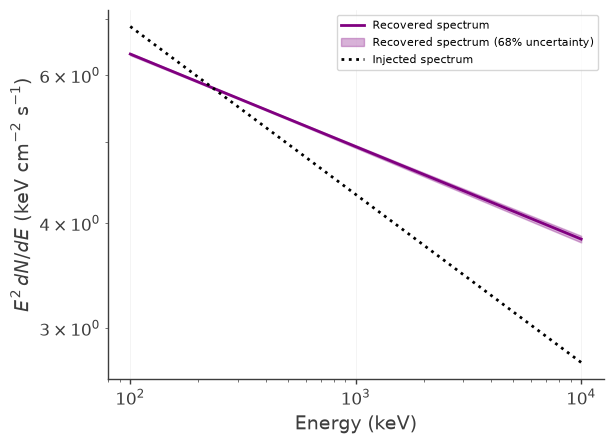

In [35]:
# Create the phase-integrated DC2 spectral comparison.
figure, axis = plt.subplots()

# Plot the median spectrum recovered by the fit.
axis.plot(
    energy_dc2,
    energy_dc2**2 * flux_median_dc2,
    color="purple",
    label="Recovered spectrum",
)

# Display the propagated 68% uncertainty as a shaded region.
axis.fill_between(
    energy_dc2,
    energy_dc2**2 * flux_low_dc2,
    energy_dc2**2 * flux_high_dc2,
    color="purple",
    alpha=0.3,
    label="Recovered spectrum (68% uncertainty)",
)

# Plot the known spectrum used to generate the DC2 simulation.
axis.plot(
    energy_dc2,
    energy_dc2**2 * flux_injected_dc2,
    color="black",
    linestyle=":",
    label="Injected spectrum",
)

# Both axes span several orders of magnitude.
axis.set_xscale("log")
axis.set_yscale("log")

axis.set_xlabel("Energy (keV)")
axis.set_ylabel(
    r"$E^2\,dN/dE$ (keV cm$^{-2}$ s$^{-1}$)"
)

axis.grid(alpha=0.25)
axis.legend()

plt.show()

In [36]:
################################################################################
# Evaluate the fitted model in detector-count space.                            #
################################################################################

# Calculate the Crab counts predicted by the fitted spectrum after passing
# through the detector response.
fitted_source_counts_dc2 = response_dc2.expectation(
    copy=True
)

# Calculate the fitted background counts using the optimized normalization.
fitted_background_counts_dc2 = background_model_dc2.expectation(
    copy=True
)

# The complete prediction must contain both components because the observed
# data contain Crab events and background events together.
fitted_total_counts_dc2 = (
    fitted_source_counts_dc2
    + fitted_background_counts_dc2
)

print(
    "Observed total counts:",
    data_dc2.data.contents.sum(),
)

print(
    "Fitted total counts:",
    fitted_total_counts_dc2.contents.sum(),
)

Observed total counts: <COO: shape=(), dtype=float64, nnz=0, fill_value=263551272.0>
Fitted total counts: 263551269.56234694


In [40]:
################################################################################
# Compare the fitted total prediction with the observed DC2 counts.             #
################################################################################

# Obtain the measured-energy bin edges.
em_edges_dc2 = data_dc2.axes["Em"].edges.value

# Calculate the center of each measured-energy bin for plotting the data.
em_centers_dc2 = 0.5 * (
    em_edges_dc2[:-1]
    + em_edges_dc2[1:]
)

# Project the multidimensional observed data onto measured energy.
observed_em_dc2 = (
    data_dc2.data
    .project("Em")
    .to_dense(copy=False)
    .contents
)

# Project the complete fitted prediction onto the same energy axis.
#
# This prediction includes both the fitted Crab and fitted background.
fitted_total_em_dc2 = (
    fitted_total_counts_dc2
    .project("Em")
    .to_dense(copy=False)
    .contents
)

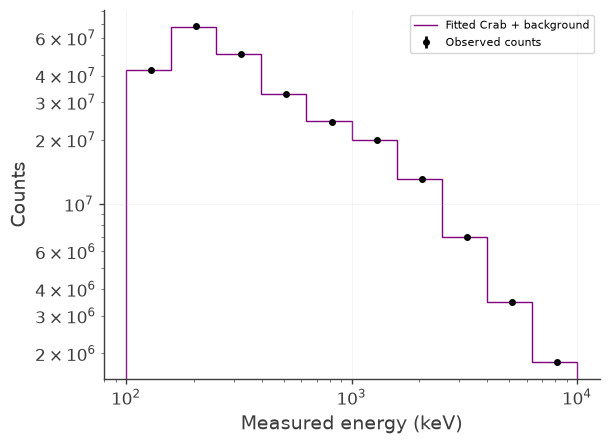

In [39]:
################################################################################
# Plot the observed counts and the complete fitted prediction.                  #
################################################################################

figure, axis = plt.subplots()

# Plot the fitted Crab-plus-background prediction as a histogram.
axis.stairs(
    fitted_total_em_dc2,
    em_edges_dc2,
    color="purple",
    label="Fitted Crab + background",
)

# Plot the observed counts at the center of each measured-energy bin.
#
# The square root of the observed counts approximates the Poisson uncertainty.
axis.errorbar(
    em_centers_dc2,
    observed_em_dc2,
    yerr=np.sqrt(observed_em_dc2),
    color="black",
    marker="o",
    linestyle="none",
    markersize=4,
    label="Observed counts",
)

axis.set_xscale("log")
axis.set_yscale("log")

axis.set_xlabel("Measured energy (keV)")
axis.set_ylabel("Counts")

axis.grid(alpha=0.25)
axis.legend()

plt.show()

In [ ]:
# Fit Interpretation

# The recovered spectrum differs from the injected spectrum because the fit can
# exchange counts between the Crab and background components. The fitted Crab
# contains more counts, while the fitted background contains nearly the same
# number of fewer counts. These differences compensate, causing the combined
# Crab-plus-background prediction to match the observed total counts.